In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import random
import seaborn as sns
import os
import shutil
from PIL import Image

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, Activation
from tensorflow.keras.layers import MaxPooling2D
from tensorflow.keras.layers import Flatten
from tensorflow.keras.layers import Dense
from tensorflow.keras.layers import SeparableConv2D
from tensorflow.keras.layers import BatchNormalization
from tensorflow.keras.layers import Dropout
from tensorflow.keras.preprocessing.image import ImageDataGenerator, load_img
from tensorflow.keras.callbacks import ModelCheckpoint
from tensorflow.keras import optimizers
from tensorflow.keras import layers
from keras import regularizers

from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from tensorflow.keras.layers import Input, Flatten, Dense
from tensorflow.keras.optimizers import Adam
from sklearn.metrics import classification_report, accuracy_score
import numpy as np

In [4]:
#Check number of classes in Brain tumor directory
base_dir = 'Brain Tumor Data Set/Brain Tumor Data Set'  # Replace with your actual path
def count_classes(directory):
    return len([name for name in os.listdir(directory) if os.path.isdir(os.path.join(directory, name))])

classes = count_classes(base_dir)

print(f"Number of classes in the dataset : {classes}")


Number of classes in the dataset : 2


In [6]:
# Set the directory paths for Tumor and Healthy images
Tumor = "Brain Tumor Data Set/Brain Tumor Data Set/Brain Tumor"
Healthy = "Brain Tumor Data Set/Brain Tumor Data Set/Healthy"

In [7]:
# Define the paths for train, validation, and test directories
train_dir = 'Brain Tumor Data Set/train'
val_dir = 'Brain Tumor Data Set/val'
test_dir = 'Brain Tumor Data Set/test'

 # Create directories for train, val, and test with subfolders for Brain Tumor and Healthy
os.makedirs(os.path.join(train_dir, 'Brain Tumor'), exist_ok=True)
os.makedirs(os.path.join(train_dir, 'Healthy'), exist_ok=True)
os.makedirs(os.path.join(val_dir, 'Brain Tumor'), exist_ok=True)
os.makedirs(os.path.join(val_dir, 'Healthy'), exist_ok=True)
os.makedirs(os.path.join(test_dir, 'Brain Tumor'), exist_ok=True)
os.makedirs(os.path.join(test_dir, 'Healthy'), exist_ok=True)

 # Function to split dataset into train, val, and test sets
def split_data(src_dir, dest_train, dest_val, dest_test, train_pct=0.7, val_pct=0.2, test_pct=0.1):
     # Handle both Tumor and Healthy categories separately
    for category, category_dir in zip(['Brain Tumor', 'Healthy'], [Tumor, Healthy]):
         # Get all files in the category folder
        files = os.listdir(category_dir)
        random.shuffle(files)  # Shuffle the files
        
         # Calculate the number of files for each split
        total_files = len(files)
        train_count = int(total_files * train_pct)
        val_count = int(total_files * val_pct)
        test_count = total_files - train_count - val_count  # Remaining files go to test
            
     # Ensure the sum of counts does not exceed total files
        if  train_count + val_count + test_count != total_files: 
            test_count = total_files - train_count - val_count
        
         # Split the files into training, validation, and testing
        for i, file in enumerate(files):
            src_file = os.path.join(category_dir, file)
            
             # Move to the appropriate folder (train/val/test) based on split
            if i < train_count:
                shutil.copy(src_file, os.path.join(dest_train, category, file))
            elif i < train_count + val_count:
                shutil.copy(src_file, os.path.join(dest_val, category, file))
            else:
                shutil.copy(src_file, os.path.join(dest_test, category, file))

 # Split both the Tumor and Healthy data
split_data(Tumor, train_dir, val_dir, test_dir)
split_data(Healthy, train_dir, val_dir, test_dir)

print("Data split completed!")

Data split completed!


In [8]:
# Function to count the number of images in a directory
def count_images(directory):
    return len([file for file in os.listdir(directory) if file.endswith(('png', 'jpg', 'jpeg'))])

# Count the number of images in each subfolder of the 'Train' directory
brain_tumor_images_train = count_images(os.path.join(train_dir, 'Brain Tumor'))
healthy_images_train = count_images(os.path.join(train_dir, 'Healthy'))
brain_tumor_images_val = count_images(os.path.join(val_dir, 'Brain Tumor'))
healthy_images_val = count_images(os.path.join(val_dir, 'Healthy')) 
brain_tumor_images_test = count_images(os.path.join(test_dir, 'Brain Tumor'))
healthy_images_test = count_images(os.path.join(test_dir, 'Healthy'))


# Print the results
print(f"Number of Brain Tumor images in train directory: {brain_tumor_images_train}")
print(f"Number of Healthy images in train directory: {healthy_images_train}")
print(f"Number of Brain Tumor images in validation directory: {brain_tumor_images_val}")
print(f"Number of Healthy images in validation directory: {healthy_images_val}")
print(f"Number of Brain Tumor images in test directory: {brain_tumor_images_test}")
print(f"Number of Healthy images in test directory: {healthy_images_test}")

Number of Brain Tumor images in train directory: 2359
Number of Healthy images in train directory: 2081
Number of Brain Tumor images in validation directory: 1991
Number of Healthy images in validation directory: 1707
Number of Brain Tumor images in test directory: 1378
Number of Healthy images in test directory: 1196


### *The above code has resulted in some duplication of data for each sub directories, anyhow we are gonna work with this*

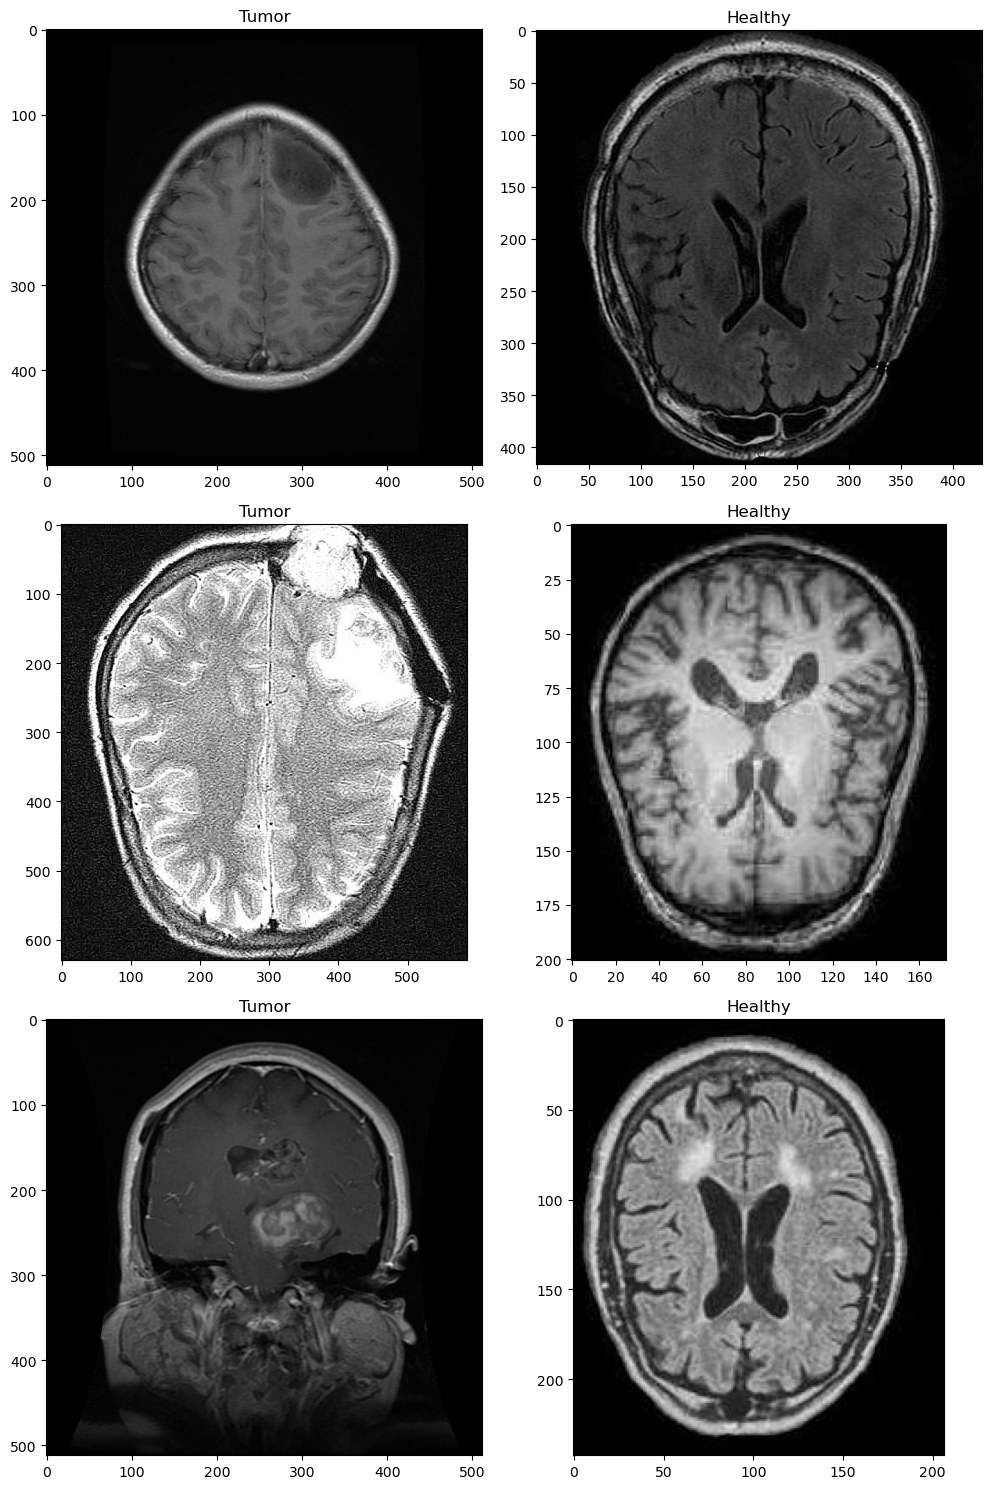

In [9]:
# Choose a random image from the Brain Tumor and Healthy directories
random_tumor_image = random.sample(os.listdir(Tumor),3)
random_healthy_image = random.sample(os.listdir(Healthy),3)

# Open the selected images
tumor_images = [Image.open(os.path.join(Tumor, image)) for image in random_tumor_image]
healthy_images = [Image.open(os.path.join(Healthy, image)) for image in random_healthy_image]

# Create a figure for displaying the images
figure = plt.figure(figsize=(10,15))

# Display the tumor images in the first column of subplots
for i in range(3):
    subplot = figure.add_subplot(3, 2, 2 * i + 1)
    plt.imshow(tumor_images[i])
    subplot.set_title(f"Tumor")

# Display the healthy images in the second column of subplots
for i in range(3):
    subplot = figure.add_subplot(3, 2, (2 * i) + 2)
    plt.imshow(healthy_images[i])
    subplot.set_title(f"Healthy")

# Adjust layout for better spacing
plt.tight_layout()

# Show the figure
plt.show()

In [10]:
# Define the paths for the 'Brain Tumor' and 'Healthy' directories
train_Tumor = 'Brain Tumor Data Set/train/Brain Tumor'  # Replace with the actual path to the Tumor folder
train_Healthy = 'Brain Tumor Data Set/train/Healthy'  # Replace with the actual path to the Healthy folder

# Choose 3 random images from each directory
random_tumor_images = random.sample(os.listdir(train_Tumor), 3)  # 3 unique tumor images
random_healthy_images = random.sample(os.listdir(train_Healthy), 3)  # 3 unique healthy images

# Function to get image shape
def get_image_shape(image_path):
    with Image.open(image_path) as img:
        img_array = np.array(img)  # Convert image to numpy array
        return img_array.shape  # Returns shape (height, width, channels)

# Print image shapes for Tumor images
print("Tumor images shapes:")
for image in random_tumor_images:
    image_path = os.path.join(Tumor, image)
    shape = get_image_shape(image_path)
    print(f"Image: {image} | Shape: {shape}")

# Print image shapes for Healthy images
print("\nHealthy images shapes:")
for image in random_healthy_images:
    image_path = os.path.join(Healthy, image)
    shape = get_image_shape(image_path)
    print(f"Image: {image} | Shape: {shape}")


Tumor images shapes:
Image: Cancer (15).jpg | Shape: (512, 512, 3)
Image: Cancer (1339).jpg | Shape: (353, 300, 3)
Image: Cancer (1580).jpg | Shape: (630, 628, 3)

Healthy images shapes:
Image: Not Cancer  (719).jpg | Shape: (213, 236, 3)
Image: Not Cancer  (1784).jpg | Shape: (198, 150, 3)
Image: Not Cancer  (1658).jpg | Shape: (680, 680, 3)


### *WE can see that we don't have a gernalized shape of images in both classes so we will assumen that test and validation also don't have gernalized shape. Hence we will preprocess and Augemnt are data*.

In [12]:
#joining both directories into training data and testing data and validation data
gen = ImageDataGenerator(shear_range=0.2,horizontal_flip=True,rescale=1./255, zoom_range=(0.99,0.99)) #will be used for both training and validation data
test_gen = ImageDataGenerator(rescale=1.0/255)

In [14]:
# Training data 
train = gen.flow_from_directory("Brain Tumor Data Set/train",
                               target_size = (128,128),
                               batch_size = 256,
                               color_mode = "rgb",
                               class_mode = "binary",
                               shuffle = True)

Found 4600 images belonging to 2 classes.


In [16]:
#Validation data
val = gen.flow_from_directory("Brain Tumor Data Set/val",
                               target_size = (128,128),
                               batch_size = 256,
                               color_mode = "rgb",
                               class_mode = "binary",
                               shuffle = True)

Found 3824 images belonging to 2 classes.


In [18]:
test = test_gen.flow_from_directory("Brain Tumor Data Set/test",
                               target_size = (128,128),
                               color_mode = "rgb",
                               class_mode = "binary",
                               shuffle = False)

Found 2667 images belonging to 2 classes.


In [20]:
train.image_shape

(128, 128, 3)

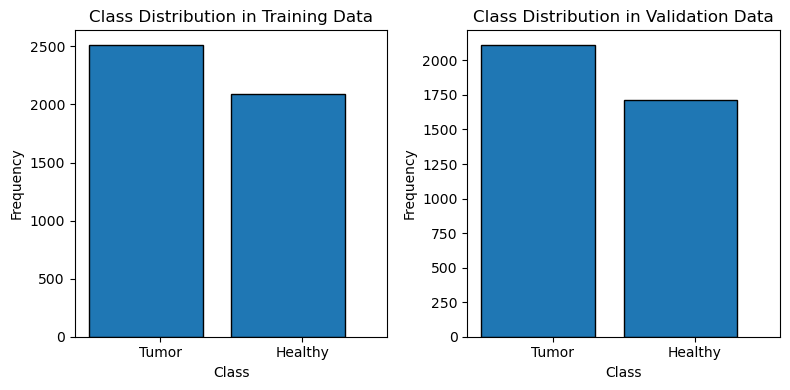

In [21]:
# Get the labels from the train and validation data generators
labels = train.labels
labels_val = val.labels

# Create the subplots (1 row, 2 columns)
plt.figure(figsize=(8, 4))

# Plot the histogram for training data (subplot 1)
plt.subplot(1, 2, 1)
n, bins, patches = plt.hist(labels, bins=2, edgecolor='black', alpha=1, width=0.4)

# Set the labels for the x-axis (0: Tumor, 1: Healthy) at the center of each bar
bar_centers = (bins[:-1] + bins[1:]) / 2  # Calculate the center of each bar
plt.xticks(bar_centers, ['Tumor', 'Healthy'])

# Set the title and axis labels for the training data histogram
plt.title('Class Distribution in Training Data')
plt.xlabel('Class')
plt.ylabel('Frequency')

# Plot the histogram for validation data (subplot 2)
plt.subplot(1, 2, 2)
n_val, bins_val, patches_val = plt.hist(labels_val, bins=2, edgecolor='black', alpha=1, width=0.4)

# Set the labels for the x-axis (0: Tumor, 1: Healthy) at the center of each bar for validation data
bar_centers_val = (bins_val[:-1] + bins_val[1:]) / 2  # Calculate the center of each bar
plt.xticks(bar_centers_val, ['Tumor', 'Healthy'])

# Set the title and axis labels for the validation data histogram
plt.title('Class Distribution in Validation Data')
plt.xlabel('Class')
plt.ylabel('Frequency')

# Show the histograms
plt.tight_layout()  # Adjust layout for better spacing
plt.show()


In [ ]:
# model = Sequential()

# model.add(Conv2D(32,(3,3),activation="relu", input_shape=(128,128,3),padding='same',name="conv_1.1"))
# model.add(Conv2D(32,(3,3),activation="relu",name="conv_1.2"))
# model.add(MaxPooling2D((2,2),name="pool_1"))

# model.add(SeparableConv2D(64,(3,3),activation="relu",name="conv_2.1"))
# model.add(SeparableConv2D(64,(3,3),activation="relu",name="conv_2.2"))
# model.add(MaxPooling2D((2,2),name="pool_2"))

# model.add(SeparableConv2D(64,(3,3),name="conv_3.1"))
# model.add(BatchNormalization(name='bn_3.1'))
# model.add(Activation("relu"))
# model.add(SeparableConv2D(64,(3,3),activation="relu",name="conv_3.2"))
# model.add(MaxPooling2D((2,2),name="pool_3"))

# model.add(SeparableConv2D(128,(3,3),name="conv_4.1"))
# model.add(BatchNormalization(name='bn_4.1'))
# model.add(Activation("relu"))
# model.add(SeparableConv2D(128,(3,3),activation="relu",name="conv_4.2"))
# model.add(MaxPooling2D((2,2),name="pool_4"))

# model.add(Flatten())

# model.add(Dense(activation="relu",units=128, kernel_regularizer=regularizers.l2(0.01)))
# model.add(Dropout(0.3,name="Drop_2"))

# model.add(Dense(activation="sigmoid",units=1))


In [ ]:
model = Sequential()

model.add(layers.InputLayer(input_shape=(128, 128, 3)))
model.add(layers.Conv2D(filters=32, kernel_size=3, activation="relu", padding="same"))
model.add(layers.MaxPooling2D())
model.add(layers.Conv2D(filters=64, kernel_size=3, activation="relu", padding="same"))
model.add(layers.MaxPooling2D())

model.add(layers.Flatten())

model.add(layers.Dense(128, activation='relu'))
model.add(layers.BatchNormalization())
model.add(layers.Dropout(rate=0.3))
model.add(layers.Dense(64, activation="relu"))
model.add(layers.BatchNormalization())
model.add(layers.Dropout(rate=0.3))
model.add(layers.Dense(1, activation="sigmoid"))

In [ ]:
from keras import utils, callbacks
earlystopping = callbacks.EarlyStopping(monitor="val_loss", mode="min", 
                                        patience=5, restore_best_weights = True)

In [ ]:
adam_optimizer = optimizers.Adam(learning_rate=0.001)
model.compile(optimizer=adam_optimizer,loss="binary_crossentropy", metrics=['accuracy'])

In [ ]:
model.summary()

In [ ]:
from keras import utils, callbacks
earlystopping = callbacks.EarlyStopping(monitor="val_loss", mode="min", 
                                        patience=5, restore_best_weights = True)

In [ ]:
history = model.fit(train,verbose=1,epochs=20,validation_data=val,callbacks = [earlystopping])

In [ ]:
#evaluating the model on test data
test_accuracy = model.evaluate(test),
test_accuracy

In [ ]:
plt.plot(history.history['accuracy'], label='accuracy')
plt.plot(history.history['val_accuracy'], label = 'val_accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.ylim([0, 1])
plt.legend(loc='lower right')

In [ ]:
plt.plot(history.history['loss'], label='loss')
plt.plot(history.history['val_loss'], label = 'val_loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.ylim([0, 1])
plt.legend(loc='lower right')

In [ ]:
model.save('model.keras')

### *Testing Code*

In [28]:
from tensorflow.keras.models import load_model
from tensorflow.keras.preprocessing import image

# Load the pre-trained model once
model1 = load_model("model.keras")

# Load and preprocess the image
img_path = 'Test_h.jpg'
img_size = (128, 128)

# Load image and resize it to the required size
img = image.load_img(img_path, target_size=img_size)

# Convert the image to an array and normalize it
img_array = image.img_to_array(img) / 255.0

# Add an extra dimension to make it a batch of size 1 (for prediction)
img_array = np.expand_dims(img_array, axis=0)

# Perform prediction
prediction = model1.predict(img_array)

# Since it's a binary classification, we use the output directly for interpretation
prediction_value = prediction[0][0]

# Output prediction result
if prediction_value > 0.5:
    print(f"Healthy: {prediction_value * 100:.2f}%")
else:
    print(f"Tumor: {(1 - prediction_value) * 100:.2f}%")


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 95ms/step
Healthy: 93.53%


84/84 ━━━━━━━━━━━━━━━━━━━━ 6s 76ms/step


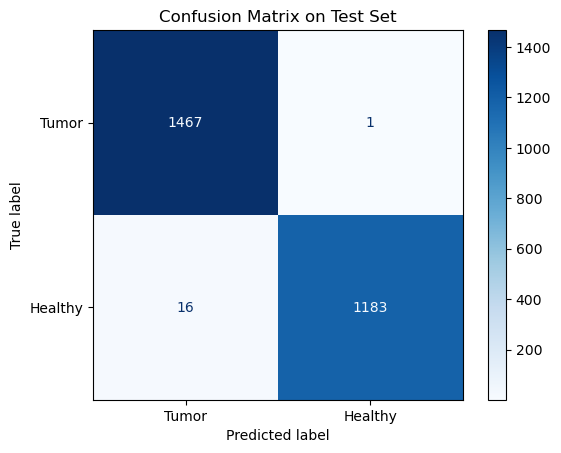

In [32]:
# Ensure your test generator has shuffle=False
# so that labels correspond to predictions
test.reset()

# Predict probabilities on the test set
y_pred_prob = model1.predict(test)              # Shape: (num_samples, 1)
y_pred = (y_pred_prob > 0.5).astype(int)      # Convert to 0 or 1

# True labels
y_true = test.labels                           # test.labels is from ImageDataGenerator

# Compute confusion matrix
cm = confusion_matrix(y_true, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Tumor', 'Healthy'])

# Plot
disp.plot(cmap=plt.cm.Blues)
plt.title("Confusion Matrix on Test Set")
plt.show()

### *Linear regression*

In [26]:
# Define a simple linear model with one hidden layer
model2 = Sequential([
    Input(shape=(128,128,3)),
    Flatten(), 
    #Dense(128, activation='relu'),
    Dense(1, activation='sigmoid') 
])
# Compile the model
model2.compile(
    optimizer=Adam(0.001),     
    loss='binary_crossentropy',    
    metrics=['accuracy']         
)
# Train the model
history = model2.fit(
    train,                  
    validation_data=val,  
    epochs=10               
)

C:\Users\nikov\anaconda3\Lib\site-packages\keras\src\trainers\data_adapters\py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/10
18/18 ━━━━━━━━━━━━━━━━━━━━ 90s 5s/step - accuracy: 0.6148 - loss: 0.8296 - val_accuracy: 0.7401 - val_loss: 0.5540
Epoch 2/10
18/18 ━━━━━━━━━━━━━━━━━━━━ 47s 3s/step - accuracy: 0.7337 - loss: 0.5438 - val_accuracy: 0.7398 - val_loss: 0.5294
Epoch 3/10
18/18 ━━━━━━━━━━━━━━━━━━━━ 79s 3s/step - accuracy: 0.7720 - loss: 0.4939 - val_accuracy: 0.8075 - val_loss: 0.4612
Epoch 4/10
18/18 ━━━━━━━━━━━━━━━━━━━━ 42s 2s/step - accuracy: 0.7993 - loss: 0.4663 - val_accuracy: 0.8183 - val_loss: 0.4352
Epoch 5/10
18/18 ━━━━━━━━━━━━━━━━━━━━ 39s 2s/step - accuracy: 0.7948 - loss: 0.4644 - val_accuracy: 0.7351 - val_loss: 0.5050
Epoch 6/10
18/18 ━━━━━━━━━━━━━━━━━━━━ 36s 2s/step - accuracy: 0.8059 - loss: 0.4409 - val_accuracy: 0.8426 - val_loss: 0.4003
Epoch 7/10
18/18 ━━━━━━━━━━━━━━━━━━━━ 34s 2s/step - accuracy: 0.8217 - loss: 0.4204 - val_accuracy: 0.8237 - val_loss: 0.4183
Epoch 8/10
18/18 ━━━━━━━━━━━━━━━━━━━━ 34s 2s/step - accuracy: 0.8559 - loss: 0.3811 - val_accuracy: 0.8776 - val_loss:

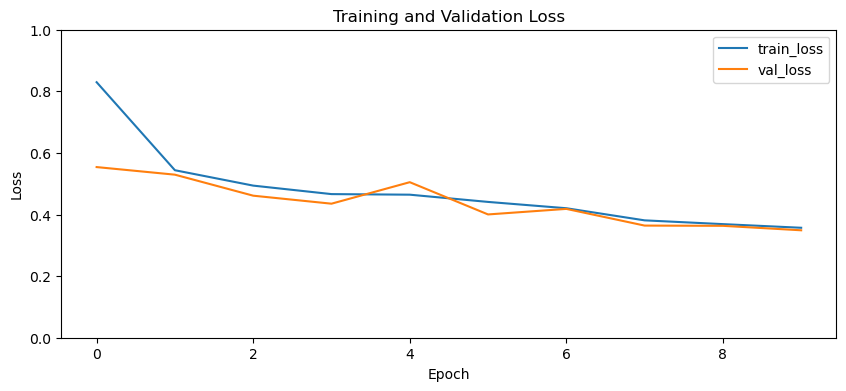

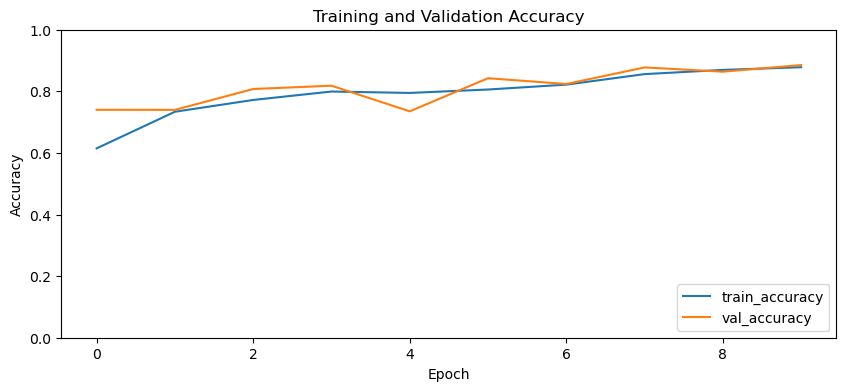

In [33]:
# Plot Loss
plt.figure(figsize=(10,4))
plt.plot(history.history['loss'], label='train_loss')
plt.plot(history.history['val_loss'], label='val_loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.ylim([0, 1])
plt.title('Training and Validation Loss')
plt.legend(loc='upper right')
plt.show()

# Plot Accuracy
plt.figure(figsize=(10,4))
plt.plot(history.history['accuracy'], label='train_accuracy')
plt.plot(history.history['val_accuracy'], label='val_accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.ylim([0, 1])
plt.title('Training and Validation Accuracy')
plt.legend(loc='lower right')
plt.show()

In [39]:
testing_accuracy = model2.evaluate(test)

84/84 ━━━━━━━━━━━━━━━━━━━━ 4s 52ms/step - accuracy: 0.8774 - loss: 0.3481


In [41]:
from tensorflow.keras.models import load_model
from tensorflow.keras.preprocessing import image

# Load the pre-trained model once
model1 = load_model("model.keras")

# Load and preprocess the image
img_path = 'Test_h.jpg'
img_size = (128, 128)

# Load image and resize it to the required size
img = image.load_img(img_path, target_size=img_size)

# Convert the image to an array and normalize it
img_array = image.img_to_array(img) / 255.0

# Add an extra dimension to make it a batch of size 1 (for prediction)
img_array = np.expand_dims(img_array, axis=0)

# Perform prediction
prediction = model2.predict(img_array)

# Since it's a binary classification, we use the output directly for interpretation
prediction_value = prediction[0][0]

# Output prediction result
if prediction_value > 0.5:
    print(f"Healthy: {prediction_value * 100:.2f}%")
else:
    print(f"Tumor: {(1 - prediction_value) * 100:.2f}%")


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
Healthy: 92.29%


84/84 ━━━━━━━━━━━━━━━━━━━━ 4s 53ms/step
84/84 ━━━━━━━━━━━━━━━━━━━━ 7s 82ms/step


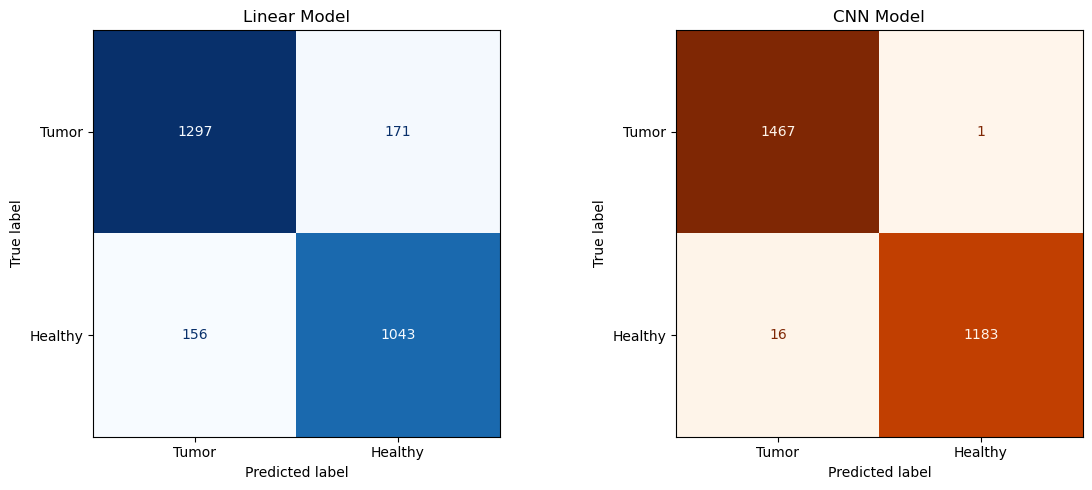

In [37]:
# Make sure test generator has shuffle=False
test.reset()

# Predictions for model 1 (e.g., linear model)
y_pred1 = (model2.predict(test) > 0.5).astype(int)
y_true = test.labels
cm1 = confusion_matrix(y_true, y_pred1)

# Predictions for model 2 (e.g., CNN model)
y_pred2 = (model1.predict(test) > 0.5).astype(int)
cm2 = confusion_matrix(y_true, y_pred2)

# Plot both confusion matrices side by side
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

disp1 = ConfusionMatrixDisplay(confusion_matrix=cm1, display_labels=['Tumor', 'Healthy'])
disp1.plot(ax=axes[0], cmap=plt.cm.Blues, colorbar=False)
axes[0].set_title('Linear Model')

disp2 = ConfusionMatrixDisplay(confusion_matrix=cm2, display_labels=['Tumor', 'Healthy'])
disp2.plot(ax=axes[1], cmap=plt.cm.Oranges, colorbar=False)
axes[1].set_title('CNN Model')

plt.tight_layout()
plt.show()

### *Scores*

In [44]:
test.reset()

# Predictions for linear model
y_pred1 = (model2.predict(test) > 0.5).astype(int)
y_true = test.labels
print("=== Linear Model ===")
print("Accuracy:", accuracy_score(y_true, y_pred1))
print(classification_report(y_true, y_pred1, target_names=['Tumor', 'Healthy']))

# Predictions for CNN model
y_pred2 = (model1.predict(test) > 0.5).astype(int)
print("=== CNN Model ===")
print("Accuracy:", accuracy_score(y_true, y_pred2))
print(classification_report(y_true, y_pred2, target_names=['Tumor', 'Healthy']))

84/84 ━━━━━━━━━━━━━━━━━━━━ 4s 52ms/step
=== Linear Model ===
Accuracy: 0.8773903262092239
              precision    recall  f1-score   support

       Tumor       0.89      0.88      0.89      1468
     Healthy       0.86      0.87      0.86      1199

    accuracy                           0.88      2667
   macro avg       0.88      0.88      0.88      2667
weighted avg       0.88      0.88      0.88      2667

84/84 ━━━━━━━━━━━━━━━━━━━━ 6s 76ms/step
=== CNN Model ===
Accuracy: 0.9936257967754031
              precision    recall  f1-score   support

       Tumor       0.99      1.00      0.99      1468
     Healthy       1.00      0.99      0.99      1199

    accuracy                           0.99      2667
   macro avg       0.99      0.99      0.99      2667
weighted avg       0.99      0.99      0.99      2667

